# Reconstructing my Irazu UCS model with a transparent Python FDEM solver

This notebook revisits the 50 mm × 100 mm UCS specimen from my Geomechanica Irazu assignment. My aim is to understand and expose the mechanics: intact finite-element deformation, cohesive fracture, platen loading, explicit integration, and numerical verification.

This is not presented as a clone of Irazu. I use the Irazu result as an independent reference and state the simplifications of my Python model explicitly.


## 1. Computational model

The rock is discretized with mildly irregular constant-strain triangles. I duplicate the nodes of every triangle, then connect neighbouring faces with four-node, zero-thickness cohesive elements. Before failure the interfaces transfer normal and shear traction. After progressive damage they can separate; closed failed faces retain compression and Coulomb friction.

The top and bottom boundaries follow smooth rigid-platen kinematics. Lateral deformation is free away from the ends, while the platen interfaces use the specified 6-degree Coulomb friction. A half-cosine loading ramp avoids introducing the full platen velocity in one explicit time step.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

# This works inside the repository and when the notebook is opened directly in Colab.
candidates = [Path.cwd(), Path.cwd().parent]
project_root = next((p for p in candidates if (p / "fdem_ucs").exists()), None)
if project_root is None:
    checkout = Path("/content/Computational-rock-mechanics-portfolio")
    if not checkout.exists():
        subprocess.run([
            "git", "clone", "--depth", "1",
            "https://github.com/Kalu2724/Computational-rock-mechanics-portfolio.git",
            str(checkout),
        ], check=True)
    project_root = checkout / "01_ucs_brittle_failure" / "python_fdem"

sys.path.insert(0, str(project_root))
reference_csv = project_root.parent / "data" / "stress_strain data.csv"

from fdem_ucs import ModelConfig, run_ucs
from fdem_ucs.validation import comparison_metrics, run_mechanical_checks
from fdem_ucs.visualization import (
    load_irazu_reference,
    plot_energy_balance,
    plot_fracture_evolution,
    plot_model_setup,
    plot_response_comparison,
)

print(f"Project root: {project_root}")


Project root: C:\Users\kalue\OneDrive\Desktop\Python\Python_FDEM_Implementation\01_ucs_brittle_failure\python_fdem


## 2. Governing equations

The semi-discrete mechanical balance is

$$
\mathbf{M}\ddot{\mathbf{u}}+\mathbf{C}\dot{\mathbf{u}}
=\mathbf{f}_{\mathrm{bulk}}+\mathbf{f}_{\mathrm{coh}}+\mathbf{f}_{\mathrm{contact}}.
$$

For a constant-strain triangle,

$$
\boldsymbol{\varepsilon}=\mathbf{B}\mathbf{u}^{e},\qquad
\boldsymbol{\sigma}=\mathbf{D}\boldsymbol{\varepsilon},\qquad
\mathbf{f}^{e}_{\mathrm{bulk}}=-tA\mathbf{B}^{\mathsf T}\boldsymbol{\sigma}.
$$

A co-rotational update removes rigid rotation before the element strain is calculated. This matters after a crack divides the specimen into rotating fragments.

For an interface, the displacement jump is resolved into opening and slip,

$$
o=\llbracket\mathbf{u}\rrbracket\cdot\mathbf{n},\qquad
s=\llbracket\mathbf{u}\rrbracket\cdot\mathbf{t}.
$$

The shear capacity depends on compression through

$$
f_s=c+\sigma_c\tan\phi.
$$

The mixed-mode damage measure follows the normalized Mode I and Mode II separations. To avoid damage caused only by small compatibility errors in the reduced mesh, softening is activated after the mean adjacent-element stress satisfies a tensile or Mohr--Coulomb check. Damage is irreversible and the post-peak traction uses the Munjiza softening function reported in the Irazu theory manual.


## 3. Input parameters and the micro-to-macro calibration

The geometry, elastic constants, density, cohesion, tensile strength, friction angle and fracture energies come from the assignment. The model exposes one additional scalar, `interface_strength_scale`. I calibrated this scalar against the original peak UCS because microscopic cohesive parameters do not transfer one-to-one between different meshes and cohesive/contact implementations.

Only that scalar is calibrated. The crack path, random field, loading history and fracture energies are not adjusted interface by interface.


In [2]:
config = ModelConfig()
inputs = pd.Series(config.to_dict(), name="value").to_frame()
inputs.loc[[
    "width", "height", "nominal_element_size", "young_modulus",
    "poisson_ratio", "density", "tensile_strength", "cohesion",
    "friction_angle_deg", "mode_i_fracture_energy",
    "mode_ii_fracture_energy", "interface_strength_scale",
    "random_seed",
]]


,value
width,0.05
height,0.1
nominal_element_size,0.005
young_modulus,30000000000.0
poisson_ratio,0.2
density,2200.0
tensile_strength,2500000.0
cohesion,10000000.0
friction_angle_deg,35.0
mode_i_fracture_energy,9.4


## 4. Mechanical checks before simulation

I check the mesh area and mass, a constant-strain patch, rigid-body rotation, cohesive action–reaction balance, and the endpoints and monotonicity of the softening law. These checks are deliberately independent of the final UCS value.


In [3]:
checks = run_mechanical_checks(config)
display(checks)
assert checks["passed"].all(), "A mechanical verification check failed."


,check,measured,tolerance,passed
0,mesh area,0.000000e+00,1.000000e-12,True
1,lumped mass,1.734723e-18,1.000000e-12,True
2,rigid-body objectivity,2.236010e-04,1.000000e-03,True
3,constant-strain patch,1.031756e-04,1.000000e-02,True
4,cohesive action-reaction,1.507943e-14,1.000000e-10,True
5,softening endpoints/monotonicity,0.000000e+00,1.000000e-12,True


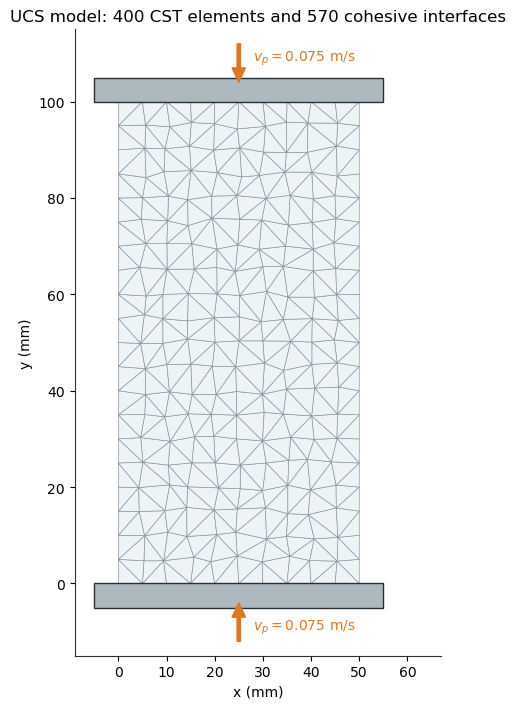

In [4]:
# Build and inspect the mesh without starting the long explicit run.
preview_config = ModelConfig(target_axial_strain=1.0e-5)
preview = run_ucs(preview_config, verbose=False)
plot_model_setup(preview)
plt.show()


## 5. Explicit UCS simulation

The default mesh has 400 triangles and 570 cohesive interfaces. On a typical laptop the full run takes about one to three minutes. The solver stores output snapshots rather than every explicit step.


In [ ]:
result = run_ucs(config)
result.history.tail()


## 6. Global validation against the Irazu result

Agreement in peak strength is useful, but it is not sufficient. I also compare peak strain, the pre-peak slope, the complete overlapping curve, and the pre-peak kinetic-to-internal-energy ratio.


In [ ]:
reference = load_irazu_reference(reference_csv)
metrics = comparison_metrics(result, reference)
display(metrics.to_frame())
plot_response_comparison(result, reference)
plt.show()


## 7. Fracture localization

The background shows axial compressive stress. Crack lines are plotted only when interface damage exceeds 0.65; this avoids turning small elastic interface motion into a visually misleading “fracture network.” Blue denotes opening-dominated damage, orange denotes shear-dominated damage, and purple denotes mixed mode.


In [ ]:
plot_fracture_evolution(result, damage_threshold=0.65)
plt.show()


## 8. Energy audit

A displacement-controlled brittle failure is dynamic near and after the peak, so kinetic energy is expected to rise during localization. Before peak, the kinetic/internal ratio is the main quasi-static diagnostic. The energy residual is reported rather than hidden; the fracture-dissipation curve is a diagnostic estimate based on the mixed-mode damage increment.


In [ ]:
plot_energy_balance(result)
plt.show()

result.history[[
    "axial_strain_percent", "axial_stress_mpa", "maximum_damage",
    "kinetic_to_internal_ratio", "energy_residual_j",
]].tail(10)


## 9. What I conclude from this reconstruction

- The intact response is controlled by the CST bulk formulation and the finite cohesive penalty.
- Localization begins when the evolving interface tractions reach the mixed-mode envelope; a crack is therefore an interface state change, not a coloured mesh edge added during plotting.
- The original Irazu result is a validation target. A close peak alone does not prove the implementations are equivalent.
- The late post-peak motion should be interpreted cautiously because this Python version handles closure of originally neighbouring faces but does not run a global search for contact between arbitrary fragments.

The next useful checks are a three-seed ensemble, a 4–6 mm mesh study, and a loading-rate study. I would show those beside the representative run before treating the calibrated multiplier as transferable.
